In [2]:
!pip install pandas

In [11]:
import pandas as pd

url = r"C:\Users\R\Downloads\archive\weatherHistory.csv"
df = pd.read_csv(url)

print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [23]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'],utc=True)

print(df.isnull().sum())

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [15]:
df['Precip Type'] = df['Precip Type'].fillna('no data')

In [19]:
print(df.describe())

       Temperature (C)  Apparent Temperature (C)      Humidity  \
count     96453.000000              96453.000000  96453.000000   
mean         11.932678                 10.855029      0.734899   
std           9.551546                 10.696847      0.195473   
min         -21.822222                -27.716667      0.000000   
25%           4.688889                  2.311111      0.600000   
50%          12.000000                 12.000000      0.780000   
75%          18.838889                 18.838889      0.890000   
max          39.905556                 39.344444      1.000000   

       Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
count       96453.000000            96453.000000     96453.000000     96453.0   
mean           10.810640              187.509232        10.347325         0.0   
std             6.913571              107.383428         4.192123         0.0   
min             0.000000                0.000000         0.000000         0.0   


In [21]:
print(f"mean of temprature: {df['Temperature (C)'].mean()}")

mean of temprature: 11.93267843751188


In [26]:
df['month'] = df['Formatted Date'].dt.month

monthly_avg_temp = df.groupby('month')['Temperature (C)'].mean()

print(monthly_avg_temp)

month
1      0.815678
2      2.166880
3      6.914976
4     12.769200
5     16.874455
6     20.728510
7     22.965462
8     22.339134
9     17.503458
10    11.334119
11     6.587549
12     1.625086
Name: Temperature (C), dtype: float64


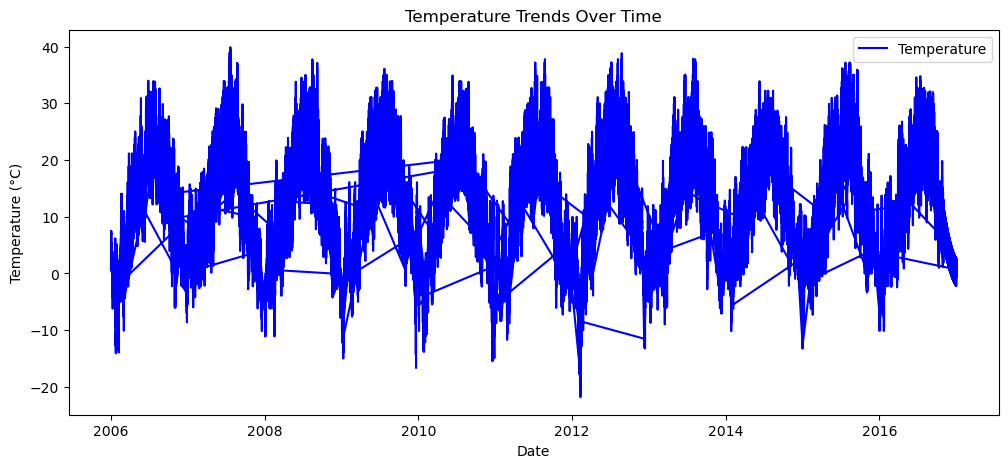

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line plot of temperature over time
plt.figure(figsize=(12, 5))
plt.plot(df['Formatted Date'], df['Temperature (C)'], label="Temperature", color="blue")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trends Over Time")
plt.legend()
plt.show()


In [29]:
print(df[['Temperature (C)', 'Humidity']].corr())


                 Temperature (C)  Humidity
Temperature (C)         1.000000 -0.632255
Humidity               -0.632255  1.000000


In [31]:
hottest_day = df[df['Temperature (C)'] == df['Temperature (C)'].max()]
coldest_day = df[df['Temperature (C)'] == df['Temperature (C)'].min()]
print("Hottest Day:\n", hottest_day)
print("Coldest Day:\n", coldest_day)


Hottest Day:
                  Formatted Date Summary Precip Type  Temperature (C)  \
12759 2007-07-22 13:00:00+00:00   Clear        rain        39.905556   

       Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
12759                 37.538889      0.13            23.5865   

       Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
12759                   250.0            9.982         0.0   

       Pressure (millibars)                             Daily Summary  month  
12759               1007.55  Partly cloudy starting in the afternoon.      7  
Coldest Day:
                  Formatted Date Summary Precip Type  Temperature (C)  \
54847 2012-02-10 06:00:00+00:00   Foggy        snow       -21.822222   

       Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
54847                -21.822222       0.8             3.0751   

       Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
54847                   323.0           1.3685         0.0   

       Pressure 